# Disclaimer: We had imbalance in TR,

### If we are using TR with L2 then we are taking 1100 values from each L1 for TR to match L2 data,

### If we are using TR alone then we are taking 2167 -> 2159 (after nan removal) (for balance between all L1 in TR)

In [1]:
 # Required packages
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/New_experiments/Shining-Through-Data.csv")
df.head()

,Unnamed: 0,afile,alang,akorp,astatus,sentlength,ppron,possdet,indef,cconj,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,6,9,en,preprocessed,L2,51.875000,0.060241,0.004819,0.002410,2.500000,...,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es
1,8,11,en,preprocessed,L2,22.769231,0.064189,0.037162,0.003378,0.538462,...,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de
2,9,12,en,preprocessed,L2,21.866667,0.054878,0.006098,0.006098,0.666667,...,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de
3,19,22,en,preprocessed,L2,34.916667,0.124105,0.023866,0.004773,1.750000,...,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es
4,20,23,en,preprocessed,L2,18.636364,0.039024,0.017073,0.000000,0.909091,...,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de


In [3]:
df = df.drop(columns="sentlength",axis = "columns")
df = df.drop(columns=["Unnamed: 0","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})


num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)


# Count of L1 per L2
count_per_L2 = df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)



Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167


In [4]:
# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df["L1_num"] = df["L1"].map(l1_map)


# define mapping
dataset_map = {
    "L2": 0,
    "TR": 1,
}

# apply mapping
df["dataset_name_map"] = df["dataset_name"].map(dataset_map)


In [5]:
# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df["L1_num"] = df["L1"].map(l1_map)


# define mapping
dataset_map = {
    "L2": 0,
    "TR": 1,
}

# apply mapping
df["dataset_name_map"] = df["dataset_name"].map(dataset_map)


In [6]:
# Data balancing across entire data set
df_L2 = df[df['dataset_name'] == 'L2']
df_TR = df[df['dataset_name'] == 'TR']

df_TR_downsampled_1100 = (
    df_TR
    .groupby('L1', group_keys=False)
    .sample(n=1100, random_state=42)
)

df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)


In [7]:
df_balanced_1100

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,L1_num,dataset_name_map
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.0,0.0,2.250000,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,1,0
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.0,0.0,0.384615,...,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.0,0.0,0.200000,...,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.0,0.0,1.750000,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,1,0
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.0,0.0,0.500000,...,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,TR,0.008929,0.008929,0.000000,1.500000,0.000000,0.000000,0.0,0.0,0.500000,...,0.250000,0.125000,0.000000,0.000000,0.000000,0.000000,0.125000,it,3,1
8796,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3,1
8797,TR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,it,3,1
8798,TR,0.000000,0.010870,0.000000,1.000000,0.000000,0.500000,0.0,0.0,0.000000,...,0.166667,0.166667,0.333333,0.000000,0.333333,0.000000,0.000000,it,3,1


#KMEANS across entire dataset: K=2, K=4

## K=2 (dropping NaN values from df_balanced1100 instead of directly df)

/tmp/ipython-input-3067159975.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_balanced_1100['cluster'] = kmeans.fit_predict(X)


dataset_name
L2    4400
TR    4388
Name: count, dtype: int64
cluster
0    5157
1    3631
Name: count, dtype: int64
Clustering Accuracy: 0.7504551661356396
Cluster    L2    TR
True               
L2       3682   718
TR       1475  2913

Classification Report:
               precision    recall  f1-score   support

          L2     0.7140    0.8368    0.7705      4400
          TR     0.8023    0.6639    0.7265      4388

    accuracy                         0.7505      8788
   macro avg     0.7581    0.7503    0.7485      8788
weighted avg     0.7581    0.7505    0.7486      8788



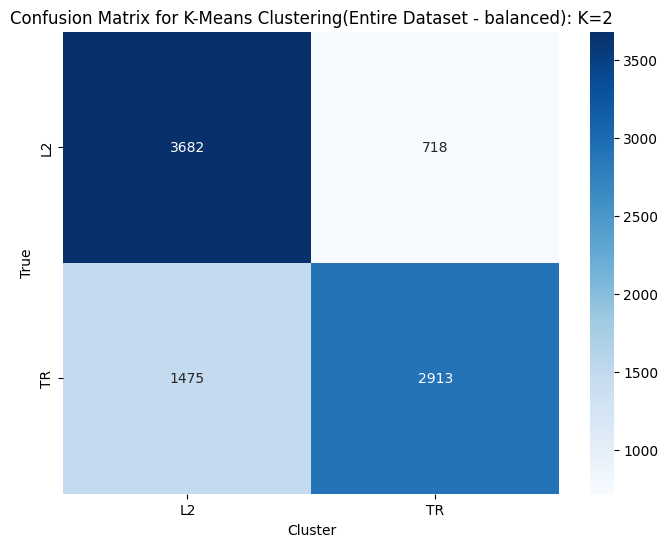

In [8]:
df_balanced_1100 = df_balanced_1100.dropna()
df_temp = df_balanced_1100.drop(['dataset_name','L1','dataset_name_map'], axis='columns')


X = df_temp.values

kmeans = KMeans(n_clusters=2, random_state=42)
df_balanced_1100['cluster'] = kmeans.fit_predict(X)

print(df_balanced_1100['dataset_name'].value_counts())
print(df_balanced_1100['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_balanced_1100['dataset_name']
y_pred = df_balanced_1100['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering(Entire Dataset - balanced): K=2')
plt.show()
df_balanced_1100 = df_balanced_1100.drop('cluster',axis = 'columns')

# K=2 Dropping the Nan First then creating df_balanced_1100 for classification

### Issue persist with only K=2 for other K =4 and NN methods the results are same.


In [9]:

df = df.dropna()

# Data balancing across entire data set
df_L2 = df[df['dataset_name'] == 'L2']
df_TR = df[df['dataset_name'] == 'TR']

df_TR_downsampled_1100 = (
    df_TR
    .groupby('L1', group_keys=False)
    .sample(n=1100, random_state=42)
)

df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)

df_TR_downsampled_2159 = (
    df_TR
    .groupby('L1', group_keys=False)
    .sample(n=2159, random_state=42)
)
df_TR_downsampled_2159 = df_TR_downsampled_2159.dropna()

df_balanced_2159 = pd.concat([df_L2, df_TR_downsampled_2159], ignore_index=True)

dataset_name
L2    4400
TR    4400
Name: count, dtype: int64
cluster
0    4400
1    4400
Name: count, dtype: int64
Clustering Accuracy: 0.5
Cluster    L2
True         
L2       4400
TR       4400


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
               precision    recall  f1-score   support

          L2     0.5000    1.0000    0.6667      4400
          TR     0.0000    0.0000    0.0000      4400

    accuracy                         0.5000      8800
   macro avg     0.2500    0.5000    0.3333      8800
weighted avg     0.2500    0.5000    0.3333      8800



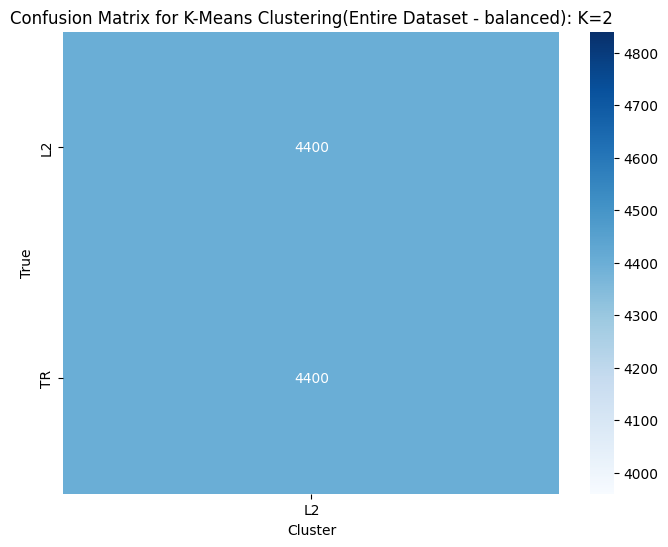

In [10]:

df_temp = df_balanced_1100.drop(['dataset_name','L1','dataset_name_map'], axis='columns')


X = df_temp.values

kmeans = KMeans(n_clusters=2, random_state=42)
df_balanced_1100['cluster'] = kmeans.fit_predict(X)

print(df_balanced_1100['dataset_name'].value_counts())
print(df_balanced_1100['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_balanced_1100['dataset_name']
y_pred = df_balanced_1100['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering(Entire Dataset - balanced): K=2')
plt.show()
df_balanced_1100 = df_balanced_1100.drop('cluster',axis = 'columns')

##K=4

L1
es    3259
de    3259
it    3259
fr    3259
Name: count, dtype: int64
cluster
0    5651
2    4431
3    2046
1     908
Name: count, dtype: int64
Clustering Accuracy: 0.3182724762196993
Cluster   es    fr    it
True                    
de       215  1556  1488
es       769  1411  1079
fr       417  1725  1117
it       645   959  1655


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000      3259
          es     0.3759    0.2360    0.2899      3259
          fr     0.3053    0.5293    0.3872      3259
          it     0.3100    0.5078    0.3850      3259

    accuracy                         0.3183     13036
   macro avg     0.2478    0.3183    0.2655     13036
weighted avg     0.2478    0.3183    0.2655     13036



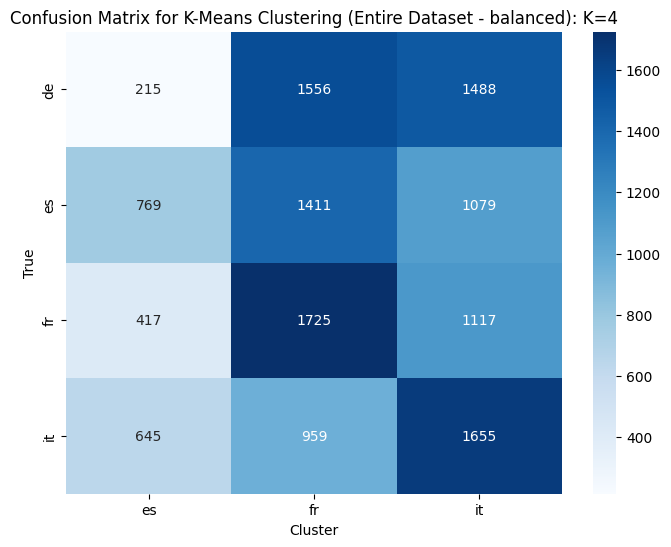

In [11]:
df_balanced_2159 = df_balanced_2159.dropna()
df_temp = df_balanced_2159.drop(['dataset_name','L1','L1_num'], axis='columns')
X = df_temp.values

kmeans = KMeans(n_clusters=4, random_state=42)
df_balanced_2159['cluster'] = kmeans.fit_predict(X)

print(df_balanced_2159['L1'].value_counts())
print(df_balanced_2159['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_balanced_2159['L1']
y_pred = df_balanced_2159['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
print(confusion_matrix)

print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (Entire Dataset - balanced): K=4')
plt.show()
df_balanced_2159 = df_balanced_2159.drop('cluster',axis = 'columns')

# Kmeans K = 4 for TR and L2

## L2

Clustering Accuracy: 0.3322727272727273

Classification Report:
               precision    recall  f1-score   support

          de     0.3144    0.8145    0.4537      1100
          es     0.3652    0.5145    0.4272      1100
          fr     0.0000    0.0000    0.0000      1100
          it     0.0000    0.0000    0.0000      1100

    accuracy                         0.3323      4400
   macro avg     0.1699    0.3323    0.2202      4400
weighted avg     0.1699    0.3323    0.2202      4400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


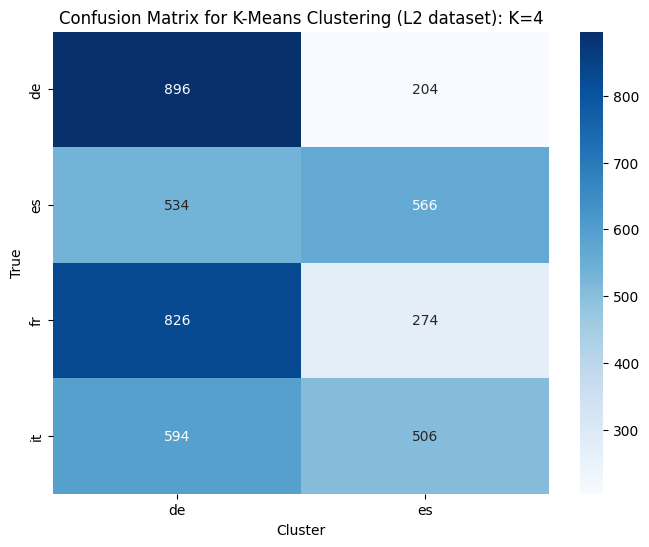

In [12]:
df_L2 = df_L2.dropna()
df_temp = df_L2.drop(['dataset_name','L1','L1_num'], axis='columns')
X = df_temp.values

kmeans = KMeans(n_clusters=4, random_state=42)
df_L2['cluster'] = kmeans.fit_predict(X)

#print(df_L2['L1'].value_counts())
#print(df_L2['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_L2['L1']
y_pred = df_L2['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
#print(confusion_matrix)


print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (L2 dataset): K=4')
plt.show()
df_L2 = df_L2.drop('cluster',axis = 'columns')

Clustering Accuracy: 0.37135247799907367


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
               precision    recall  f1-score   support

          de     0.3284    0.5424    0.4091      2159
          es     0.3496    0.5540    0.4287      2159
          fr     0.0000    0.0000    0.0000      2159
          it     0.5094    0.3891    0.4412      2159

    accuracy                         0.3714      8636
   macro avg     0.2968    0.3714    0.3197      8636
weighted avg     0.2968    0.3714    0.3197      8636



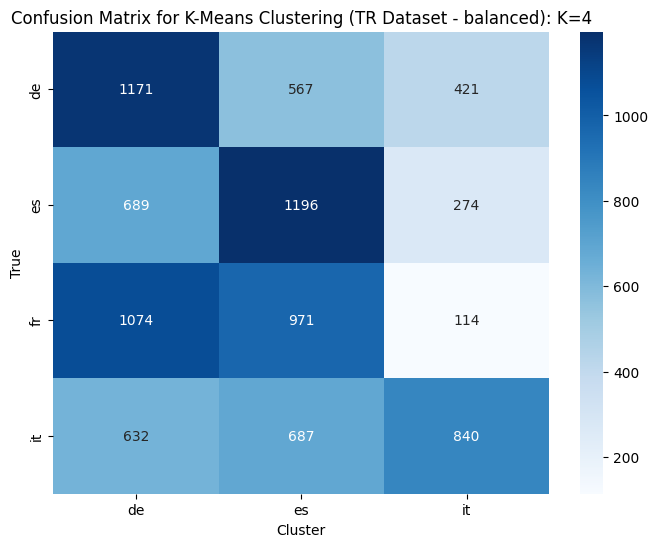

In [13]:
df_TR_downsampled_2159 = df_TR_downsampled_2159.dropna()
df_temp = df_TR_downsampled_2159.drop(['dataset_name','L1','L1_num'], axis='columns')
X = df_temp.values

kmeans = KMeans(n_clusters=4, random_state=42)
df_TR_downsampled_2159['cluster'] = kmeans.fit_predict(X)

#print(df_TR_downsampled_2159['L1'].value_counts())
#print(df_TR_downsampled_2159['cluster'].value_counts())

# Map boolean to string for readability
y_true = df_TR_downsampled_2159['L1']
y_pred = df_TR_downsampled_2159['cluster'].values

# Map clusters to majority true label
labels = np.empty_like(y_pred, dtype=object)
for cluster in np.unique(y_pred):
    mask = (y_pred == cluster)
    unique_labels, counts = np.unique(y_true[mask], return_counts=True)
    majority_label = unique_labels[np.argmax(counts)]
    labels[mask] = majority_label

# Compute accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Cluster'])
#print(confusion_matrix)


print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-Means Clustering (TR Dataset - balanced): K=4')
plt.show()
df_TR_downsampled_2159 = df_TR_downsampled_2159.drop('cluster',axis = 'columns')

# NN

## L2 on L1

In [14]:

nan_cols = ['acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
# Impute NaNs with mean per L1 group
for col in nan_cols:
    df[col] = df[col].fillna(df.groupby('L1')[col].transform('mean'))

# Verify
df[nan_cols].isna().sum()

num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)


# Data balancing across entire data set
df_L2 = df[df['dataset_name'] == 'L2']
df_TR = df[df['dataset_name'] == 'TR']

df_TR_downsampled_1100 = (
    df_TR
    .groupby('L1', group_keys=False)
    .sample(n=1100, random_state=42)
)
df_TR_downsampled_1100 = df_TR_downsampled_1100.dropna()

df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)


df_TR_downsampled_2159 = (
    df_TR
    .groupby('L1', group_keys=False)
    .sample(n=2159, random_state=42)
)
df_TR_downsampled_2159 = df_TR_downsampled_2159.dropna()

df_balanced_2159 = pd.concat([df_L2, df_TR_downsampled_2159], ignore_index=True)
df_balanced_2159 = df_balanced_2159.dropna()

Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'L1_num', 'dataset_name_map']



===== MLP Classification of L1 with L2 dataset(Test set) =====
Test Accuracy: 0.43977272727272726

Classification Report:
               precision    recall  f1-score   support

          de     0.4504    0.5364    0.4896       220
          es     0.4562    0.4500    0.4531       220
          fr     0.4180    0.3591    0.3863       220
          it     0.4292    0.4136    0.4213       220

    accuracy                         0.4398       880
   macro avg     0.4385    0.4398    0.4376       880
weighted avg     0.4385    0.4398    0.4376       880


Confusion matrix:
[[118  25  45  32]
 [ 39  99  32  50]
 [ 61  41  79  39]
 [ 44  52  33  91]]


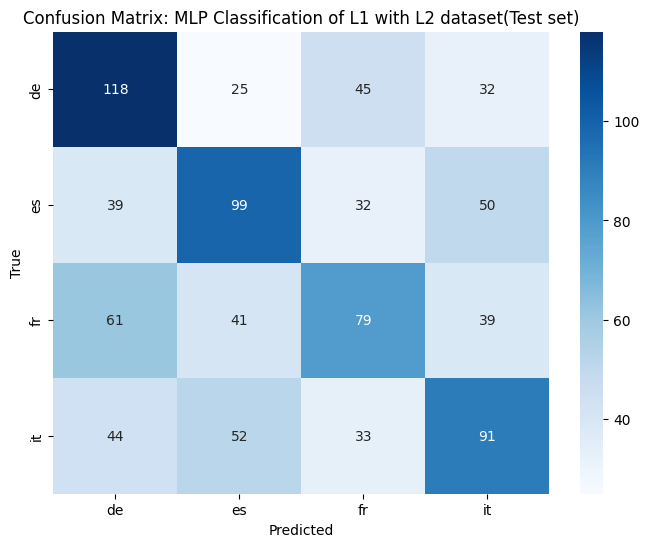

In [15]:
import scipy.sparse as sp
from sklearn.metrics import confusion_matrix



def run_nn(df, features, label_col="L1", title="Neural Network"):


    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )



    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Ensure X is dense float64

    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train_s = to_dense_float(X_train_s)
    X_test_s  = to_dense_float(X_test_s)


    # Ensure y is a plain 1D array (not sparse, not weird dtype)
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)


    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)

    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm

features = df_L2.drop(columns=["L1", "dataset_name","L1_num"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_L2, features, label_col="L1", title="MLP Classification of L1 with L2 dataset(Test set)")


## TR on L1


===== MLP Classification of L1 with TR dataset(Test set) =====
Test Accuracy: 0.6255787037037037

Classification Report:
               precision    recall  f1-score   support

          de     0.6250    0.4514    0.5242       432
          es     0.5795    0.5903    0.5849       432
          fr     0.6639    0.7454    0.7023       432
          it     0.6293    0.7153    0.6696       432

    accuracy                         0.6256      1728
   macro avg     0.6244    0.6256    0.6202      1728
weighted avg     0.6244    0.6256    0.6202      1728


Confusion matrix:
[[195  61  56 120]
 [ 50 255  83  44]
 [ 26  66 322  18]
 [ 41  58  24 309]]


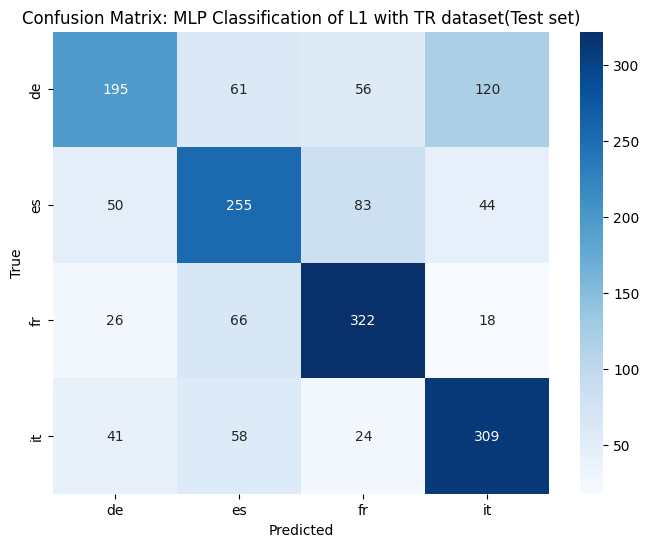

In [16]:
features = df_TR_downsampled_2159.drop(columns=["L1", "dataset_name","L1_num"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_TR_downsampled_2159, features, label_col="L1", title="MLP Classification of L1 with TR dataset(Test set)")

In [17]:
features

Index(['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied',
       'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR',
       'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals',
       'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus',
       'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple',
       'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp',
       'nsubj:pass', 'parataxis', 'xcomp', 'dataset_name_map'],
      dtype='object')

## NN Entire Data set on L1


===== MLP Classification of L1 with entire dataset(Test set) =====
Test Accuracy: 0.5724693251533742

Classification Report:
               precision    recall  f1-score   support

          de     0.5576    0.5123    0.5340       652
          es     0.5516    0.5414    0.5464       652
          fr     0.5827    0.5890    0.5858       652
          it     0.5944    0.6472    0.6197       652

    accuracy                         0.5725      2608
   macro avg     0.5716    0.5725    0.5715      2608
weighted avg     0.5716    0.5725    0.5715      2608


Confusion matrix:
[[334  79  88 151]
 [ 90 353 128  81]
 [ 95 117 384  56]
 [ 80  91  59 422]]


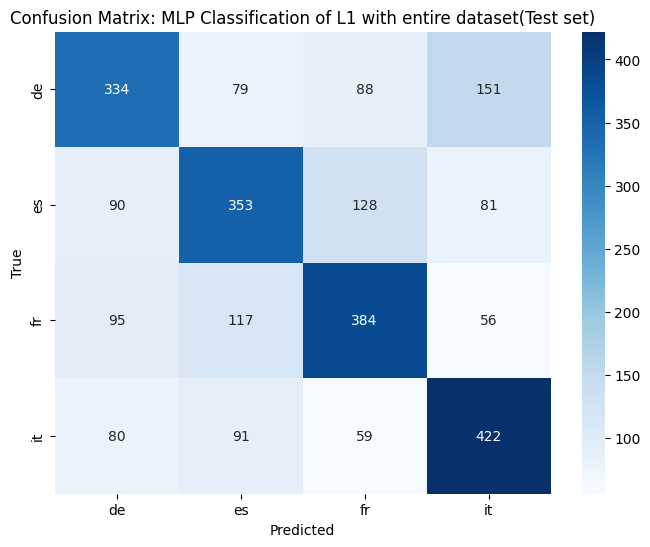

In [18]:
features = df_balanced_2159.drop(columns=["L1", "dataset_name","L1_num"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_balanced_2159, features, label_col="L1", title="MLP Classification of L1 with entire dataset(Test set)")


===== MLP Classification of L1 with entire dataset(Test set) =====
Test Accuracy: 0.5329545454545455

Classification Report:
               precision    recall  f1-score   support

          de     0.5357    0.5455    0.5405       440
          es     0.5144    0.4455    0.4775       440
          fr     0.5000    0.5545    0.5259       440
          it     0.5824    0.5864    0.5844       440

    accuracy                         0.5330      1760
   macro avg     0.5331    0.5330    0.5321      1760
weighted avg     0.5331    0.5330    0.5321      1760


Confusion matrix:
[[240  44  83  73]
 [ 66 196 110  68]
 [ 78  74 244  44]
 [ 64  67  51 258]]


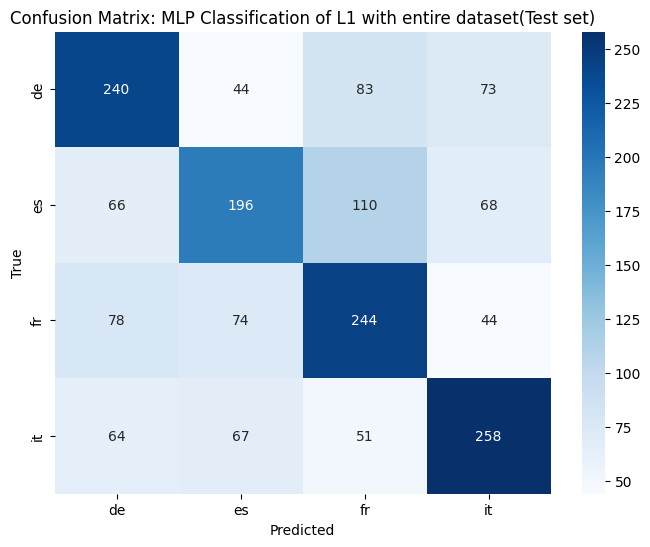

In [100]:
#if we take 1100 from TR, 1100 from L2
features = df_balanced_1100.drop(columns=["L1", "dataset_name","L1_num"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_balanced_1100, features, label_col="L1", title="MLP Classification of L1 with entire dataset(Test set)")

In [22]:
df_balanced_2159

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1,L1_num,dataset_name_map
0,L2,0.060241,0.004819,0.002410,2.500000,0.375000,1.000000,0.000000,0.0,2.250000,...,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es,1,0
1,L2,0.064189,0.037162,0.003378,0.538462,0.230769,0.307692,0.000000,0.0,0.384615,...,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de,0,0
2,L2,0.054878,0.006098,0.006098,0.666667,0.133333,0.266667,0.000000,0.0,0.200000,...,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de,0,0
3,L2,0.124105,0.023866,0.004773,1.750000,0.500000,0.333333,0.000000,0.0,1.750000,...,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es,1,0
4,L2,0.039024,0.017073,0.000000,0.909091,0.000000,0.136364,0.000000,0.0,0.500000,...,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13031,TR,0.000000,0.017544,0.000000,0.500000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.400000,0.000000,0.033333,0.000000,0.000000,0.033333,0.033333,it,3,1
13032,TR,0.000000,0.009009,0.000000,2.000000,0.000000,1.333333,0.333333,0.0,0.000000,...,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,it,3,1
13033,TR,0.000000,0.006849,0.000000,1.333333,0.000000,0.333333,0.000000,0.0,0.666667,...,0.305556,0.250000,0.055556,0.000000,0.055556,0.000000,0.000000,it,3,1
13034,TR,0.006993,0.000000,0.000000,0.600000,0.000000,0.000000,0.000000,0.0,0.600000,...,0.200000,0.000000,0.066667,0.000000,0.133333,0.000000,0.000000,it,3,1


In [27]:

pd.crosstab(df_balanced_2159['dataset_name'], df_balanced_2159['L1'])



L1,de,es,fr,it
dataset_name,,,,
L2,1100,1100,1100,1100
TR,2159,2159,2159,2159


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Neural Network Test Accuracy: 0.5463957055214724

Classification Report:
               precision    recall  f1-score   support

          de     0.5063    0.4954    0.5008       652
          es     0.5420    0.5046    0.5226       652
          fr     0.5578    0.5552    0.5565       652
          it     0.5756    0.6304    0.6018       652

    accuracy                         0.5464      2608
   macro avg     0.5454    0.5464    0.5454      2608
weighted avg     0.5454    0.5464    0.5454      2608



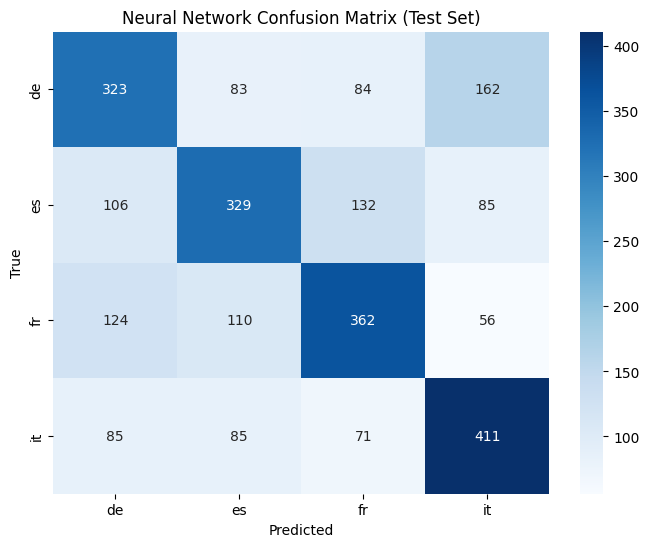

In [101]:
#Same code as shining through ipynb one

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

to_drop = [c for c in ['dataset_name','L1','L1_num'] if c in df.columns]
feature_cols = [c for c in df.columns if c not in to_drop]
df_balanced_2159 = df_balanced_2159.dropna()

X = df_balanced_2159[feature_cols].values
y = df_balanced_2159['L1'].values  # target

# Train-test split (stratify ensures class balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Ensure X is dense float64
def to_dense_float(a):
    if sp.issparse(a):
        a = a.toarray()
    return np.asarray(a, dtype=np.float64)

X_train_s = to_dense_float(X_train_s)
X_test_s  = to_dense_float(X_test_s)

# Ensure y is a plain 1D array (not sparse, not weird dtype)
y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

# Neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    early_stopping=False, validation_fraction=0.1,
    activation='relu',
    solver='adam',
    max_iter=200,  # can increase for convergence
    random_state=42
)

mlp.fit(X_train_s, y_train)

# Predict on test set
y_pred = mlp.predict(X_test_s)

# Evaluation
acc = np.mean(y_pred == y_test)
print("\nNeural Network Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
labels_order = np.unique(y_test)
conf_mat = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Neural Network Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## NN Entire dataset L2 vs TR


===== MLP Classification of L2 vs TR with entire dataset(Test set) =====
Test Accuracy: 0.9943181818181818

Confusion matrix:
[[874   6]
 [  4 876]]


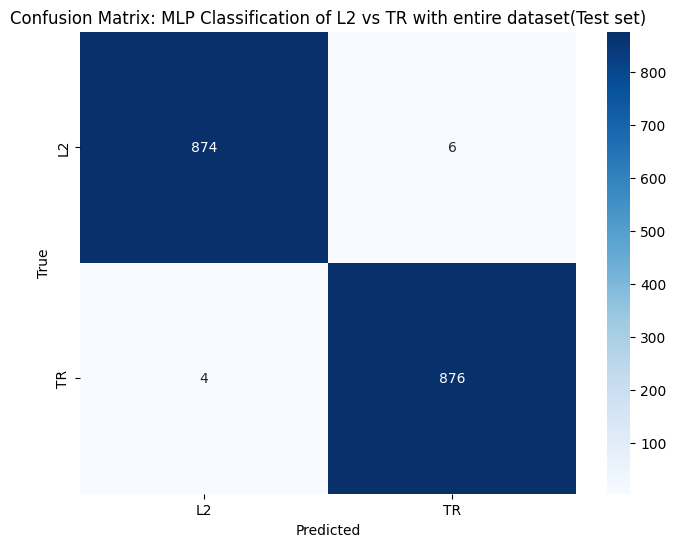

In [ ]:
def run_nn(df, features, label_col="dataset_name", title="Neural Network"):

    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)

    # define mapping
    label_map = {
        0:"L2",
        1:"TR",
    }

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm


features = df_balanced_1100.drop(columns=["L1", "dataset_name","dataset_name_map"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_balanced_1100, features, label_col="dataset_name", title="MLP Classification of L2 vs TR with entire dataset(Test set)")


===== MLP Classification of L2 vs TR with entire dataset(Test set) =====
Test Accuracy: 0.9923312883435583

Confusion matrix:
[[ 874    6]
 [  14 1714]]


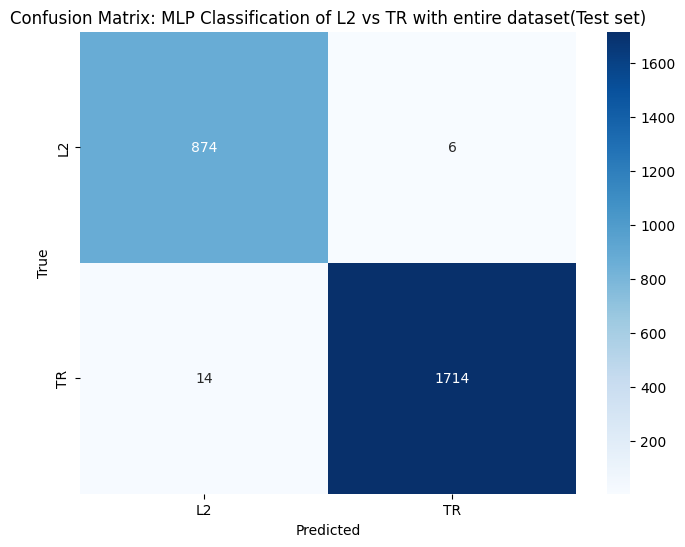

In [ ]:
# Not ideal as TR values are more
features = df_balanced_2159.drop(columns=["L1", "dataset_name","dataset_name_map"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df_balanced_2159, features, label_col="dataset_name", title="MLP Classification of L2 vs TR with entire dataset(Test set)")

In [ ]:
def train_on_source_test_on_target(
    df_source,
    df_target,
    features,
    label_col="L1",
    title=""
):
    X_train = df_source[features].values
    y_train = df_source[label_col].values

    X_test = df_target[features].values
    y_test = df_target[label_col].values



    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42
    )

    mlp.fit(X_train_s, y_train)
    y_pred = mlp.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    #print(cm)
    #print(classification_report(y_test, y_pred, digits=4))

    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]



    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    print(f"\n===== {title} =====")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, digits=4))

    return acc


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Classification Report:
               precision    recall  f1-score   support

          de     0.3493    0.4382    0.3887      1100
          es     0.2932    0.4582    0.3576      1100
          fr     0.3216    0.1500    0.2046      1100
          it     0.3731    0.2673    0.3114      1100

    accuracy                         0.3284      4400
   macro avg     0.3343    0.3284    0.3156      4400
weighted avg     0.3343    0.3284    0.3156      4400



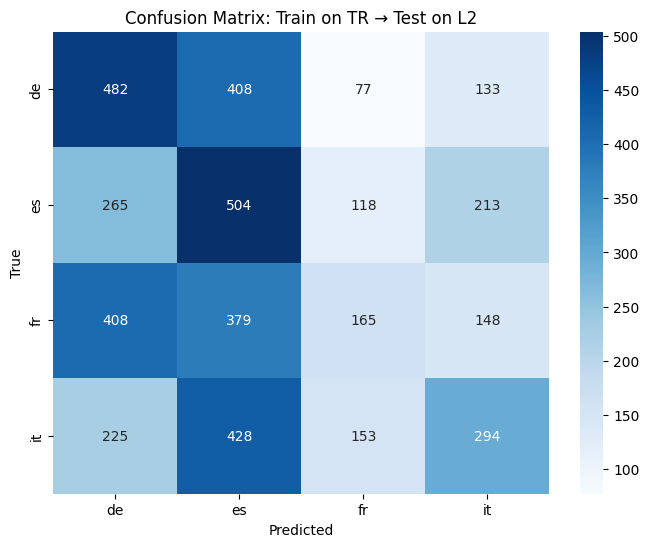


===== Train on TR → Test on L2 =====
Accuracy: 0.32840909090909093
              precision    recall  f1-score   support

           0     0.3493    0.4382    0.3887      1100
           1     0.2932    0.4582    0.3576      1100
           2     0.3216    0.1500    0.2046      1100
           3     0.3731    0.2673    0.3114      1100

    accuracy                         0.3284      4400
   macro avg     0.3343    0.3284    0.3156      4400
weighted avg     0.3343    0.3284    0.3156      4400



0.32840909090909093

In [ ]:
# TR->L2
features = (
    df_TR_downsampled_2159
    .drop(columns=["L1", "dataset_name", "L1_num"])
    .select_dtypes(include=[np.number])
    .columns
)

train_on_source_test_on_target(
    df_TR_downsampled_2159,
    df_L2,
    features,
    label_col="L1",
    title="Train on TR → Test on L2"
)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Classification Report:
               precision    recall  f1-score   support

          de     0.3661    0.1139    0.1738      2159
          es     0.2339    0.1292    0.1665      2159
          fr     0.2468    0.0440    0.0747      2159
          it     0.2493    0.7374    0.3726      2159

    accuracy                         0.2561      8636
   macro avg     0.2740    0.2561    0.1969      8636
weighted avg     0.2740    0.2561    0.1969      8636



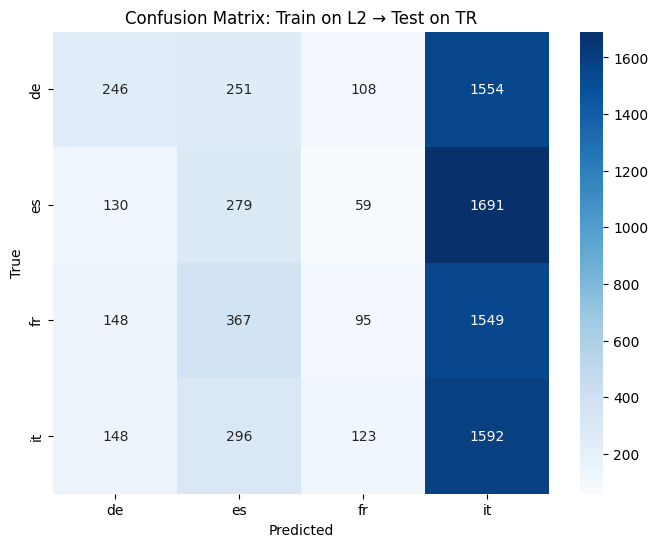


===== Train on L2 → Test on TR =====
Accuracy: 0.2561371005094951
              precision    recall  f1-score   support

           0     0.3661    0.1139    0.1738      2159
           1     0.2339    0.1292    0.1665      2159
           2     0.2468    0.0440    0.0747      2159
           3     0.2493    0.7374    0.3726      2159

    accuracy                         0.2561      8636
   macro avg     0.2740    0.2561    0.1969      8636
weighted avg     0.2740    0.2561    0.1969      8636



0.2561371005094951

In [ ]:
# L2 ->TR
train_on_source_test_on_target(
    df_L2,
    df_TR_downsampled_2159,
    features,
    label_col="L1",
    title="Train on L2 → Test on TR"
)
